# Ejercicio 3

Analogamente al ejercicio 2, creamos una tabla con los datos que necesitemos.

In [1]:
import pyvo as vo
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sp
import numpy as np

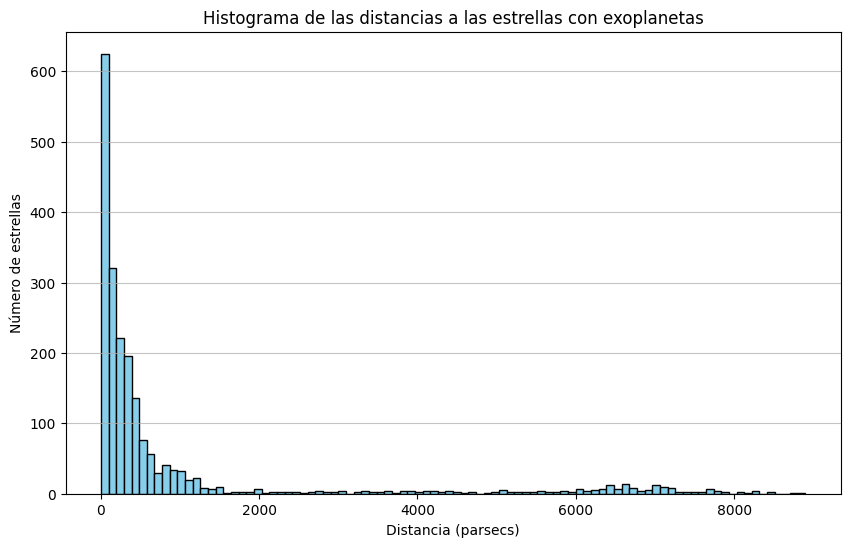

In [4]:
# seleccionamos el servidor a partir del cual vamos a buscar los datos
service = vo.dal.TAPService("http://voparis-tap-planeto.obspm.fr/tap")

query = "SELECT granule_uid,star_distance FROM exoplanet.epn_core WHERE mass < 15"
results = service.search(query)

table = results.to_table()
df = table.to_pandas()
df.set_index('granule_uid',inplace = True)
df.head()


# Histograma de las distancias a las estrellas con exoplanetas
plt.figure(figsize=(10,6))
plt.hist(df['star_distance'], bins='auto', color='skyblue', edgecolor='black')
plt.title('Histograma de las distancias a las estrellas con exoplanetas')
plt.xlabel('Distancia (parsecs)')
plt.ylabel('Número de estrellas')
plt.grid(axis='y', alpha=0.75)
plt.show()

Queremos analizar si sigue una distribucion gaussiana, para esto usamos


In [9]:
#creamos una serie con las distancias, eliminando los NaN

distancias = df['star_distance'].dropna()

# calculamos la media y la desviacion estandar
mu, sigma = distancias.mean(), distancias.std()

# calculamos la prueba de Kolmogórov-Smirnov
ks_statistic, p_value = sp.kstest(distancias, 'norm', args=(mu, sigma))

# Nivel de significancia 
alpha = 0.05

# imprimimos los resultados
print(f"Prueba de Kolmogórov-Smirnov:")
print(f"Estadístico KS = {ks_statistic:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"Nivel de significancia α = {alpha}")

if p_value > alpha:
    print("No podemos rechazar la hipótesis nula")
    print("La distribución ES consistente con una distribución gaussiana")
else:
    print("Rechazamos la hipótesis nula")
    print("La distribución NO es consistente con una distribución gaussiana")


Prueba de Kolmogórov-Smirnov:
Estadístico KS = 0.3379
p-value = 0.0000
Nivel de significancia α = 0.05
Rechazamos la hipótesis nula
La distribución NO es consistente con una distribución gaussiana
